In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load data
url = "https://raw.githubusercontent.com/TiffanyPanchum/Renewable-Energy-Prediction/refs/heads/main/data/processed/Feature_Engineering%20_Dataset/feature_engineered_data.csv"
df = pd.read_csv(url)

# Preprocessing
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# Handle missing values
features = ['temp', 'rhum', 'prcp', 'wspd', 'pres', 'hour_sin', 'hour_cos',
            'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
            'Solar_lag_1', 'Solar_lag_24', 'Solar_rolling_24h_mean']
target = 'Solar'

# Forward fill and backfill missing values
df[features] = df[features].ffill().bfill()

# Convert to numpy arrays
X = df[features].values
y = df[target].values

# Time-based split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.preprocessing import MinMaxScaler
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten()

# Sequence creation function
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Create sequences
lookback = 24
X_train_seq, y_train_seq = create_sequences(X_train, y_train_scaled, lookback)
X_test_seq, y_test_seq = create_sequences(X_test, y_test_scaled, lookback)

# Model architecture
def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Verify input shape
input_shape = (lookback, X_train.shape[1])
print("Input shape:", input_shape)
print("Training sequences shape:", X_train_seq.shape)
print("Training targets shape:", y_train_seq.shape)
print("Sample training sequence:", X_train_seq[0])
print("Corresponding target:", y_train_seq[0])

Input shape: (24, 14)
Training sequences shape: (141744, 24, 14)
Training targets shape: (141744,)
Sample training sequence: [[-1.00900549e+00  5.75949945e-01 -7.37008830e-02 -3.33087212e-01
   9.86158358e-01 -1.73515604e-04  1.41414527e+00 -6.12600417e-01
  -1.27352637e+00  6.32989382e-01  1.23058884e+00 -7.06215574e-01
  -7.05904933e-01 -1.48166746e+00]
 [-1.30448309e+00  5.20202164e-01 -7.37008830e-02 -6.43753113e-01
   1.15604824e+00 -1.73515604e-04  1.41414527e+00 -6.12600417e-01
  -1.27352637e+00  6.32989382e-01  1.23058884e+00 -7.06215574e-01
  -7.05904933e-01 -1.48166746e+00]
 [-5.79219876e-01  1.30067109e+00 -7.37008830e-02 -1.00087786e-01
   1.05896831e+00 -1.73515604e-04  1.41414527e+00 -6.12600417e-01
  -1.27352637e+00  6.32989382e-01  1.23058884e+00 -7.06215574e-01
  -7.05904933e-01 -1.48166746e+00]
 [-1.04929789e+00  6.31697726e-01 -7.37008830e-02 -8.50863714e-01
   1.01042834e+00  3.65861576e-01  1.36595838e+00 -6.12600417e-01
  -1.27352637e+00  6.32989382e-01  1.2305888

Text(0, 0.5, 'Frequency')

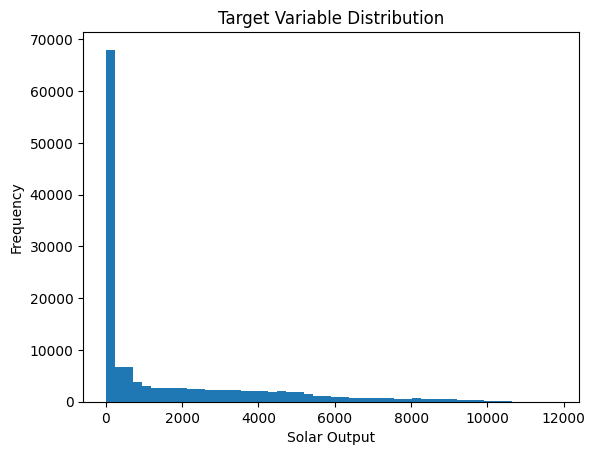

In [3]:
# Verify target distribution
plt.hist(y_train, bins=50)
plt.title("Target Variable Distribution")
plt.xlabel("Solar Output")
plt.ylabel("Frequency")

In [4]:
print((df['Solar'] == 0).sum())

49739


In [5]:
# Build and train model
model = build_lstm(input_shape)
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0121 - mae: 0.0741 - val_loss: 0.0100 - val_mae: 0.0608
Epoch 2/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0067 - mae: 0.0505 - val_loss: 0.0120 - val_mae: 0.0642
Epoch 3/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0060 - mae: 0.0480 - val_loss: 0.0097 - val_mae: 0.0616
Epoch 4/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.0057 - mae: 0.0466 - val_loss: 0.0102 - val_mae: 0.0591
Epoch 5/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0054 - mae: 0.0453 - val_loss: 0.0086 - val_mae: 0.0566
Epoch 6/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.0051 - mae: 0.0439 - val_loss: 0.0122 - val_mae: 0.0635
Epoch 7/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0048 - mae: 0.0427 - val_loss: 0.0092 - val_mae: 0.0573
Epoch 8/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.0045 - mae: 0.0414 - val_loss: 0.0083 - val_mae: 0.0562
Epoch 9/50
1772/1772 ━━━━━━━━━━

In [10]:
# Predict on test set
y_pred = model.predict(X_test_seq)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
mae = mean_absolute_error(y_test_seq, y_pred)
r2 = r2_score(y_test_seq, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test R²: {r2:.2f}")

1107/1107 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test RMSE: 0.19
Test MAE: 0.11
Test R²: 0.64


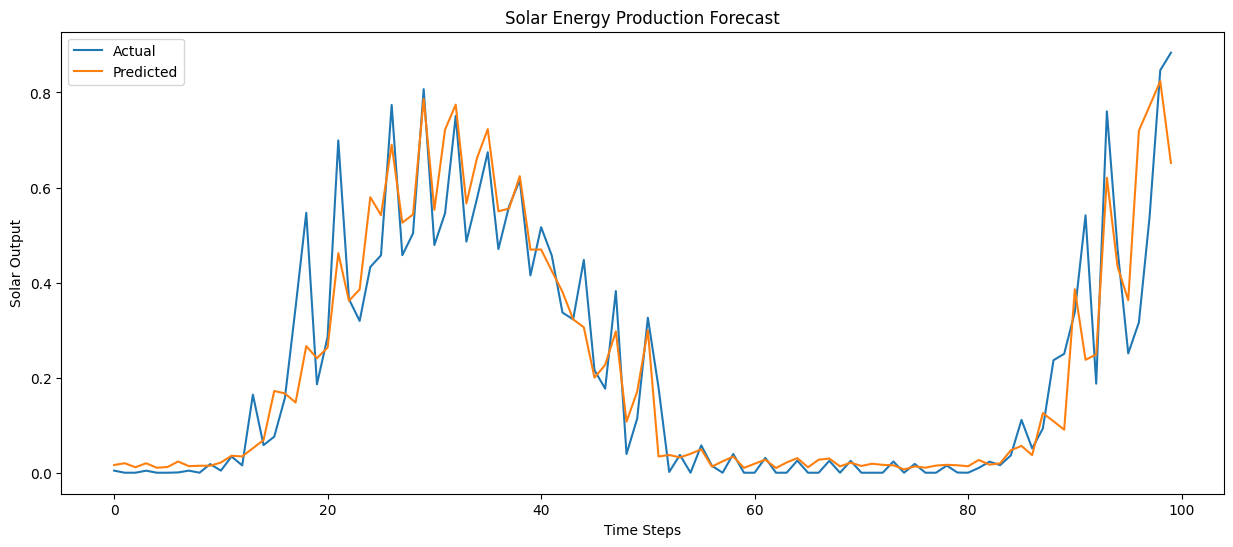

In [11]:
# Plot first 100 test samples
plt.figure(figsize=(15, 6))
plt.plot(y_test_seq[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.title("Solar Energy Production Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Solar Output")
plt.legend()
plt.show()

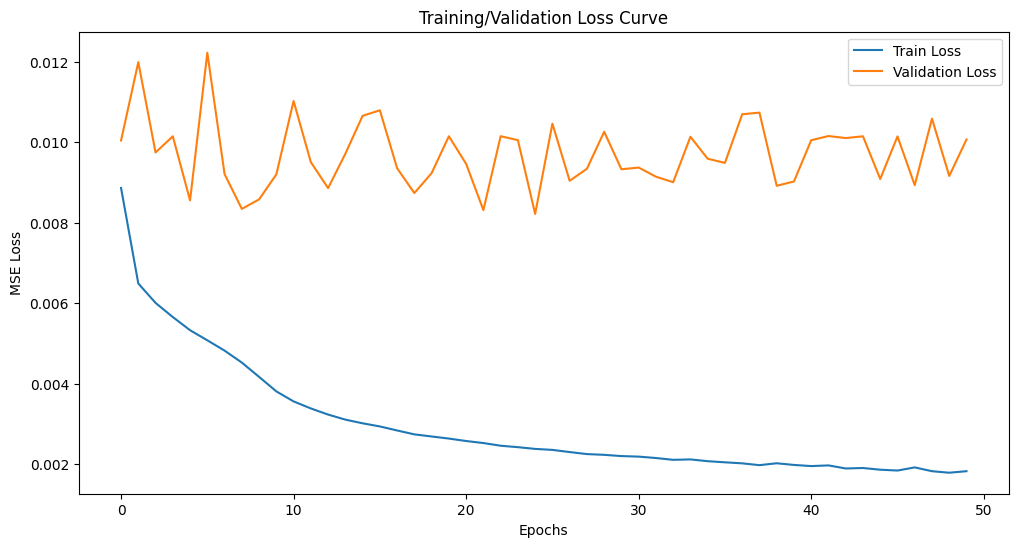

In [12]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training/Validation Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [13]:
# Save model
model.save("solar_lstm_model.keras")

# Save scalers
joblib.dump(scaler, "feature_scaler.pkl")

['feature_scaler.pkl']

In [14]:
# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Model': ['LSTM'],
    'RMSE': [rmse],
    'MAE': [mae],
    'R²': [r2]
})

# Save for later comparison
metrics_df.to_csv("model_metrics.csv", index=False)